<a href="https://colab.research.google.com/github/ivan-penta/proyecto_cidam/blob/main/proyecto_cidam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Creción del ámbiente en PySpark

In [4]:
# 1. Instalar Java 17 y PySpark
!apt-get update -qq
!apt-get install openjdk-17-jdk -y
!pip install pyspark==4.0.1 -q

# 2. Configurar variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# 3. Verificar instalación de Java
!java -version

# 4. Crear SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Analisis Compranet Big Data") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.driver.maxResultSize", "4g") \
    .getOrCreate()

print("✅ SparkSession creada")
print("Versión:", spark.version)
print("App Name:", spark.sparkContext.appName)
print("Master:", spark.sparkContext.master)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest version (17.0.18+8-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
✅ SparkSession creada
Versión: 4.0.1
App Name: Analisis Compranet Big Data
Master: local[*]


### Cargar dataset

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, expr

spark = SparkSession.builder \
    .appName("Analisis Compranet Big Data") \
    .getOrCreate()

print("📂 Cargando dataset completo de CompraNet...")


data = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("multiLine", "true") \
    .option("escape", "\"") \
    .csv("compranet_historico.csv")

data = data.withColumn(
    "importe",
    expr("try_cast(importe as double)")
)

conteo_nulos = data.filter(col("importe").isNull()).count()
print(f"⚠️ Registros con formato inválido convertidos a NULL: {conteo_nulos}")

total_registros = data.count()
print(f"📊 Total de registros procesados: {total_registros:,}")

data.write.mode("overwrite").parquet("compranet_historico.parquet")
print("💾 Dataset completo guardado exitosamente en formato Parquet.")

📂 Cargando dataset completo de CompraNet...
⚠️ Registros con formato inválido convertidos a NULL: 5188
📊 Total de registros procesados: 2,356,612
💾 Dataset completo guardado exitosamente en formato Parquet.


In [6]:
from pyspark.sql.functions import col

registros_antes=data.count()

data = data.dropna(subset=[
    "importe","ff_fecha_inicio",
    "ff_fecha_fin"
])

registros_despues = data.count()

print(f"Registros antes de limpieza: {registros_antes}")
print(f"Registros después de limpieza: {registros_despues}")
print(f"Número de registros eliminados: {registros_antes - registros_despues}")

Registros antes de limpieza: 2356612
Registros después de limpieza: 2347566
Número de registros eliminados: 9046


In [7]:
num_registros =data.count()
num_columnas = len(data.columns)

print(f"Número de registros: {num_registros}")
print(f"Número de columnas: {num_columnas}")

Número de registros: 2347566
Número de columnas: 16


### Selección de variables relevantes

In [8]:
from pyspark.sql.functions import col

df = data.select(
    "codigo_contrato",
    "codigo_expediente",
    "proveedor",
    "contract_type",
    "tipo_contratacion",
    "tipo_expediente",
    "importe",
    "moneda",
    "fecha_inicio",
    "fecha_fin"
)

df.show(5)

+---------------+-----------------+--------------------+---------------+--------------------+--------------------+----------+------+--------------------+--------------------+
|codigo_contrato|codigo_expediente|           proveedor|  contract_type|   tipo_contratacion|     tipo_expediente|   importe|moneda|        fecha_inicio|           fecha_fin|
+---------------+-----------------+--------------------+---------------+--------------------+--------------------+----------+------+--------------------+--------------------+
|        2376191|          2161394|Equity Appraisal ...|    3.Servicios|           Servicios|05. Adjudicación ...|   89012.0|   MXN|2020-07-22 05:00:...|2020-08-27 04:59:...|
|             89|              348|Si Vale Mexico Sa...|ADQUISICIONES_0|No especificado p...|V20151220 12. Adj...| 5980292.7|   MXN|2010-12-06 06:00:...|2011-01-01 05:59:...|
|           1756|              399|Metlife Mexico Sa...|    SERVICIOS_1|No especificado p...|V20110525 01. Lic...| 3904647.0|

### Converción de fechas

In [9]:
from pyspark.sql.functions import to_timestamp, col

df = df.withColumn(
    "fecha_inicio",
    to_timestamp(col("fecha_inicio"))
)

df = df.withColumn(
    "fecha_fin",
    to_timestamp(col("fecha_fin"))
)

In [10]:
df = df.filter(col("fecha_inicio").isNotNull())

#### Crear variable año

In [11]:
from pyspark.sql.functions import year

df = df.withColumn(
    "anio",
    year(col("fecha_inicio"))
)

df.select("fecha_inicio","anio").show(5)

+-------------------+----+
|       fecha_inicio|anio|
+-------------------+----+
|2020-07-22 05:00:00|2020|
|2010-12-06 06:00:00|2010|
|2011-01-01 06:00:00|2011|
|2011-01-01 06:00:00|2011|
|2011-01-01 06:00:00|2011|
+-------------------+----+
only showing top 5 rows


### Seleccionar periodo de estudio

In [12]:
df = df.filter(
    (col("anio") >= 2012) & (col("anio") <= 2024)
)
df = df.filter(df.fecha_inicio.isNotNull())

df.count()

2213776

### Variable sexenio

In [13]:
from pyspark.sql.functions import col, year, when

df = df.withColumn(
    "sexenio",
    when((col("anio") >= 2012) & (col("anio") <= 2018), "EPN")
    .when((col("anio") >= 2019) & (col("anio") <= 2024), "AMLO")
)

df.select("anio","sexenio").show(20)

+----+-------+
|anio|sexenio|
+----+-------+
|2020|   AMLO|
|2020|   AMLO|
|2020|   AMLO|
|2020|   AMLO|
|2020|   AMLO|
|2020|   AMLO|
|2020|   AMLO|
|2021|   AMLO|
|2021|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
|2022|   AMLO|
+----+-------+
only showing top 20 rows


### Contratos por sexenio

In [14]:
contratos_sexenio = df.groupBy("sexenio").count()

contratos_sexenio.show()

+-------+-------+
|sexenio|  count|
+-------+-------+
|    EPN|1438494|
|   AMLO| 775282|
+-------+-------+



### Monto total por sexenio

In [15]:
from pyspark.sql.functions import sum, format_number

monto_sexenio = df.groupBy("sexenio").agg(
    sum("importe").alias("monto_total")
)

monto_sexenio = monto_sexenio.withColumn(
    "monto_total",
    format_number("monto_total", 2)
)

monto_sexenio.select("sexenio", "monto_total").show(truncate=False)

+-------+--------------------+
|sexenio|monto_total         |
+-------+--------------------+
|EPN    |3,201,596,488,429.85|
|AMLO   |2,315,314,620,485.94|
+-------+--------------------+



### Importe promedio por contrato

In [16]:
from pyspark.sql.functions import avg
prom_sexenio = df.groupBy("sexenio").agg(
    avg("importe").alias("importe_promedio"))

prom_sexenio = prom_sexenio.withColumn(
    "importe_promedio",
    format_number("importe_promedio", 2)
)

prom_sexenio.select("sexenio", "importe_promedio").show(truncate=False)

+-------+----------------+
|sexenio|importe_promedio|
+-------+----------------+
|EPN    |2,225,658.56    |
|AMLO   |2,986,416.07    |
+-------+----------------+



### Modalidades de contratación por sexenio

In [17]:
modalidades = df.groupBy(
    "sexenio",
    "tipo_contratacion"
).count()

modalidades.orderBy("sexenio").show(50)

+-------+--------------------+------+
|sexenio|   tipo_contratacion| count|
+-------+--------------------+------+
|   AMLO|       Adquisiciones|473193|
|   AMLO|      Arrendamientos|  4382|
|   AMLO|Servicios Relacio...|  9490|
|   AMLO|        Obra Pública| 34030|
|   AMLO|            Sin dato| 13080|
|   AMLO|           Servicios|241107|
|    EPN|            Sin dato|  4326|
|    EPN|       Adquisiciones|737516|
|    EPN|           Servicios|490157|
|    EPN|        Obra Pública|166376|
|    EPN|      Arrendamientos|  8825|
|    EPN|Servicios Relacio...| 31087|
|    EPN|No especificado p...|   207|
+-------+--------------------+------+



### Porcentaje de cada modalidad

In [18]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import count

total_sexenio = df.groupBy("sexenio").agg(count("*").alias("count"))

total_sexenio = total_sexenio.withColumnRenamed("count", "total_count")
from pyspark.sql.functions import round

modalidades_pct = modalidades.join(total_sexenio, "sexenio") \
    .withColumn(
        "porcentaje",
        round(col("count") / col("total_count") * 100, 2)
    )

modalidades_pct.show()

+-------+--------------------+------+-----------+----------+
|sexenio|   tipo_contratacion| count|total_count|porcentaje|
+-------+--------------------+------+-----------+----------+
|   AMLO|       Adquisiciones|473193|     775282|     61.03|
|    EPN|            Sin dato|  4326|    1438494|       0.3|
|   AMLO|      Arrendamientos|  4382|     775282|      0.57|
|   AMLO|Servicios Relacio...|  9490|     775282|      1.22|
|    EPN|       Adquisiciones|737516|    1438494|     51.27|
|    EPN|           Servicios|490157|    1438494|     34.07|
|    EPN|        Obra Pública|166376|    1438494|     11.57|
|   AMLO|        Obra Pública| 34030|     775282|      4.39|
|   AMLO|            Sin dato| 13080|     775282|      1.69|
|    EPN|      Arrendamientos|  8825|    1438494|      0.61|
|    EPN|Servicios Relacio...| 31087|    1438494|      2.16|
|    EPN|No especificado p...|   207|    1438494|      0.01|
|   AMLO|           Servicios|241107|     775282|      31.1|
+-------+---------------

### Proveedores por sexenio

In [19]:
from pyspark.sql.functions import sum, col, format_number

# Agrupar por sexenio y proveedor, sumando el importe
proveedores_monto = df.groupBy("sexenio", "proveedor").agg(
    sum("importe").alias("monto_total")
)

proveedores_monto.orderBy(col("monto_total").desc()).select(
    "sexenio",
    "proveedor",
    format_number(col("monto_total"), 2).alias("monto")
).show(20, truncate=False)

+-------+--------------------------------------------------------------------+------------------+
|sexenio|proveedor                                                           |monto             |
+-------+--------------------------------------------------------------------+------------------+
|EPN    |Grupo Farmacos Especializados Sa de Cv                              |104,159,181,443.22|
|EPN    |Operadora Cicsa, S.A. de C.V.                                       |92,194,153,302.93 |
|AMLO   |Electromecanica de Montacargas Sa de Cv                             |64,558,297,189.50 |
|AMLO   |Toka Internacional S a P I de Cv                                    |57,112,085,062.42 |
|EPN    |Farmaceuticos Maypo, S.A. de C.V.                                   |48,544,866,462.76 |
|EPN    |Distribuidora Internacional de Medicamentos y Equipo Medico Sa de Cv|39,471,156,925.61 |
|AMLO   |Alstom Transport Mexico Sa de Cv                                    |31,520,457,949.24 |
|EPN    |Grupo Const

### Top proveedores por sexenio

In [20]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col, format_number

window = Window.partitionBy("sexenio").orderBy(col("monto_total").desc())

top_prov = proveedores_monto.withColumn(
    "rank",
    row_number().over(window)
)

top_prov.filter(col("rank") <= 10).select(
    "sexenio",
    "proveedor",
    format_number(col("monto_total"), 2).alias("monto_total"),
    "rank"
).show(truncate=False)

+-------+--------------------------------------------------------------------+------------------+----+
|sexenio|proveedor                                                           |monto_total       |rank|
+-------+--------------------------------------------------------------------+------------------+----+
|AMLO   |Electromecanica de Montacargas Sa de Cv                             |64,558,297,189.50 |1   |
|AMLO   |Toka Internacional S a P I de Cv                                    |57,112,085,062.42 |2   |
|AMLO   |Alstom Transport Mexico Sa de Cv                                    |31,520,457,949.24 |3   |
|AMLO   |Ica Constructora Sa de Cv                                           |27,851,444,297.41 |4   |
|AMLO   |Currie & Brown - Mexico Sa de Cv                                    |25,789,000,000.00 |5   |
|AMLO   |Farmaceuticos Maypo, S.A. de C.V.                                   |22,930,365,944.07 |6   |
|AMLO   |Laboratorios de Biologicos y Reactivos de Mexico Sa de Cv       

### Duración promedio de contratos

In [21]:
from pyspark.sql.functions import datediff

df = df.withColumn(
    "duración_días",
    datediff(col("fecha_fin"), col("fecha_inicio")
))

dura_sexenio = df.groupBy("sexenio").agg(
    round(avg("duración_días"), 2).alias("duración_promedio")
)

dura_sexenio.show()

+-------+-----------------+
|sexenio|duración_promedio|
+-------+-----------------+
|    EPN|           114.57|
|   AMLO|           122.94|
+-------+-----------------+



### Evolución de contratos por año

In [22]:
contrato_anio = df.groupBy("sexenio","anio").count().orderBy("anio")

contrato_anio.show()

+-------+----+------+
|sexenio|anio| count|
+-------+----+------+
|    EPN|2012|170783|
|    EPN|2013|181812|
|    EPN|2014|197294|
|    EPN|2015|222760|
|    EPN|2016|233587|
|    EPN|2017|234168|
|    EPN|2018|198090|
|   AMLO|2019|193798|
|   AMLO|2020|162073|
|   AMLO|2021|203393|
|   AMLO|2022|197385|
|   AMLO|2023| 16798|
|   AMLO|2024|  1835|
+-------+----+------+



### Evolución del gasto público

In [23]:
from pyspark.sql.functions import sum, col, format_number

monto_anio = df.groupBy("sexenio", "anio").agg(
    sum("importe").alias("monto_total")
).orderBy("anio")

monto_anio.select(
    "sexenio",
    "anio",
    format_number(col("monto_total"), 2).alias("monto total")
).show(truncate=False)

+-------+----+------------------+
|sexenio|anio|monto total       |
+-------+----+------------------+
|EPN    |2012|360,478,163,362.42|
|EPN    |2013|387,144,714,968.95|
|EPN    |2014|538,460,489,345.95|
|EPN    |2015|448,966,310,975.14|
|EPN    |2016|450,741,243,392.83|
|EPN    |2017|569,196,557,646.81|
|EPN    |2018|446,609,008,737.55|
|AMLO   |2019|410,408,021,229.65|
|AMLO   |2020|506,335,627,853.86|
|AMLO   |2021|514,451,923,327.44|
|AMLO   |2022|568,153,417,782.93|
|AMLO   |2023|292,574,473,318.73|
|AMLO   |2024|23,391,156,973.21 |
+-------+----+------------------+



### Prueba estadística entre sexenios

In [24]:
from scipy.stats import ttest_ind

pdf =df.select("sexenio","importe").toPandas()

epn = pdf[pdf["sexenio"] == "EPN"]["importe"]
amlo = pdf[pdf["sexenio"] == "AMLO"]["importe"]

t_stat, p_value = ttest_ind(epn, amlo, equal_var=False)

print("t statistic:", t_stat)
print("p-value:", p_value)

t statistic: -5.24880686416957
p-value: 1.5311163417419703e-07


### Machine Learning para diferencias sexenios

In [25]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="sexenio", outputCol="sexenio_index")
df_ml = indexer.fit(df).transform(df)

### Variables del modelo

In [26]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["importe", "duración_días", "anio"],
    outputCol="features"
)

df_ml = assembler.transform(df_ml)

### Preparar features

In [27]:
from pyspark.sql.functions import log1p, col, month, dayofweek

df_ml = df.withColumn("log_importe", log1p(col("importe"))) \
          .withColumn("mes_inicio",  month(col("fecha_inicio"))) \
          .withColumn("dia_semana",  dayofweek(col("fecha_inicio")))

print("Columnas en df_ml:", df_ml.columns)
print("Nulos en log_importe:", df_ml.filter(col("log_importe").isNull()).count())

Columnas en df_ml: ['codigo_contrato', 'codigo_expediente', 'proveedor', 'contract_type', 'tipo_contratacion', 'tipo_expediente', 'importe', 'moneda', 'fecha_inicio', 'fecha_fin', 'anio', 'sexenio', 'duración_días', 'log_importe', 'mes_inicio', 'dia_semana']
Nulos en log_importe: 0


### VectorAssembler Sin año

In [28]:
assembler = VectorAssembler(
    inputCols=[
        "log_importe",
        "duración_días",
        "mes_inicio",
        "dia_semana",
        "tipo_ohe"
    ],
    outputCol = "features",
    handleInvalid = "skip"
)

### Pipeline

In [29]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

cols_a_limpiar = ["label", "tipo_idx", "tipo_ohe", "features"]
for c in cols_a_limpiar:
    if c in df_ml.columns:
        df_ml = df_ml.drop(c)

indexer_sexenio = StringIndexer(
    inputCol="sexenio",
    outputCol="label"
)
indexer_tipo = StringIndexer(
    inputCol="tipo_contratacion",
    outputCol="tipo_idx",
    handleInvalid="keep"
)
encoder = OneHotEncoder(
    inputCols=["tipo_idx"],
    outputCols=["tipo_ohe"]
)
assembler = VectorAssembler(
    inputCols=["log_importe", "duración_días", "mes_inicio", "dia_semana", "tipo_ohe"],
    outputCol="features",
    handleInvalid="skip"
)

pipeline = Pipeline(stages=[indexer_sexenio, indexer_tipo, encoder, assembler])

pipeline_model = pipeline.fit(df_ml)
df_ml = pipeline_model.transform(df_ml)

print("Pipeline ejecutado correctamente")
df_ml.select("label", "tipo_ohe", "features").show(3, truncate=True)

Pipeline ejecutado correctamente
+-----+-------------+--------------------+
|label|     tipo_ohe|            features|
+-----+-------------+--------------------+
|  1.0|(7,[1],[1.0])|(11,[0,1,2,3,5],[...|
|  1.0|(7,[1],[1.0])|(11,[0,1,2,3,5],[...|
|  1.0|(7,[1],[1.0])|(11,[0,1,2,3,5],[...|
+-----+-------------+--------------------+
only showing top 3 rows


### Split temporal

In [30]:
from pyspark.sql.functions import col

train = df_ml.filter(
    ((col("sexenio")=="EPN") & (col("anio") <= 2016)) |
    ((col("sexenio")=="AMLO") & (col("anio") <= 2020))
)
test = df_ml.filter(
    ((col("sexenio")=="EPN") & (col("anio").isin([2017,2018]))) |
    ((col("sexenio")=="AMLO") & (col("anio").isin([2023,2024])))
)

print(f"Train: {train.count():,}  |  Test: {test.count():,}")

Train: 1,362,107  |  Test: 450,891


### Random Forest

In [31]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=100,
    maxDepth=8,
    seed=42
)
model = rf.fit(train)
pred = model.transform(test)

### Evaluación

In [32]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    val = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName=metric
    ).evaluate(pred)
    print(f"{metric:20s}: {val:.4f}")

# Matriz de confusión

from pyspark.sql.functions import when

pred.withColumn(
    "sexenio_pred",
    when(col("prediction") == 0.0, "EPN").otherwise("AMLO")
).groupBy("sexenio", "sexenio_pred").count().orderBy("sexenio").show()

# Importancia de features

import pandas as pd

feature_names = (
    ["log_importe", "duración_días", "mes_inicio", "dia_semana"]
    + [f"tipo_ohe_{i}" for i in range(model.featureImportances.size -4)]
)
importances = pd.Series(
    model.featureImportances.toArray(),
    index=feature_names[:model.featureImportances.size]
).sort_values(ascending=False)
print("\nImportancia de features:")
print(importances.head(10))

accuracy            : 0.9587
weightedPrecision   : 0.9191
weightedRecall      : 0.9587
f1                  : 0.9384
+-------+------------+------+
|sexenio|sexenio_pred| count|
+-------+------------+------+
|   AMLO|         EPN| 18633|
|    EPN|         EPN|432258|
+-------+------------+------+


Importancia de features:
duración_días    0.333096
tipo_ohe_2       0.290821
log_importe      0.090694
tipo_ohe_0       0.073625
mes_inicio       0.064939
dia_semana       0.064825
tipo_ohe_1       0.058261
tipo_ohe_3       0.020673
tipo_ohe_5       0.002075
tipo_ohe_4       0.000966
dtype: float64


## Índice de concentración de proveedores

### Gasto por proveedor y sexenio

In [33]:
from pyspark.sql.functions import sum, col, format_number

gasto_proveedor = df.groupBy(
    "sexenio",
    "proveedor"
).agg(
    sum("importe").alias("monto_proveedor")
).withColumn(
    "monto_proveedor", format_number(col("monto_proveedor"), 2)
)

gasto_proveedor.show(10)

+-------+--------------------+---------------+
|sexenio|           proveedor|monto_proveedor|
+-------+--------------------+---------------+
|   AMLO|Jose Manuel Amezc...|   1,764,806.47|
|    EPN|Cadena Farmaceuti...| 398,469,243.35|
|    EPN|Basculas y Sistem...|      70,668.00|
|    EPN|Integracion de Ar...|   7,293,020.89|
|    EPN|Las Murallas de C...| 121,872,471.26|
|    EPN|   Suplimex Sa de Cv| 218,362,598.13|
|    EPN|Diesel y Lubrican...|  51,384,195.96|
|    EPN|Proveedores Indus...| 217,967,594.12|
|   AMLO|Zona Comercial Ri...|   3,735,680.00|
|    EPN|Constructora Cami...|  10,310,746.28|
+-------+--------------------+---------------+
only showing top 10 rows


### Gasto total por sexenio

In [34]:
gasto_total_sexenio = df.groupBy(
    "sexenio"
).agg(
    sum("importe").alias("gasto_total")
).withColumn(
    "gasto_total", format_number(col("gasto_total"), 2)
)

gasto_total_sexenio.show()

+-------+--------------------+
|sexenio|         gasto_total|
+-------+--------------------+
|    EPN|3,201,596,488,429.85|
|   AMLO|2,315,314,620,485.94|
+-------+--------------------+



### Participación de mercado

In [35]:
from pyspark.sql.functions import sum, col

gasto_proveedor = df.groupBy("sexenio", "proveedor").agg(
    sum("importe").alias("monto_proveedor")
)

gasto_total_sexenio = df.groupBy("sexenio").agg(
    sum("importe").alias("gasto_total")
)

participacion = gasto_proveedor.alias("gp").join(
    gasto_total_sexenio.alias("gt"),
    col("gp.sexenio") == col("gt.sexenio")
).withColumn(
    "participacion",
    col("monto_proveedor") / col("gasto_total")
).select(
    col("gp.sexenio").alias("sexenio"),
    "proveedor",
    "monto_proveedor",
    "gasto_total",
    "participacion"
)

### Cálculo del HHI

In [36]:
from pyspark.sql.functions import pow

hhi = participacion.withColumn(
    "participacion_cuadrada",
    pow(col("participacion"),2)
)

hhi_sexenio = hhi.groupBy(
    "sexenio"
).agg(
    sum("participacion_cuadrada").alias("HHI")
)

hhi_sexenio.show()

+-------+--------------------+
|sexenio|                 HHI|
+-------+--------------------+
|    EPN|0.003152571290035251|
|   AMLO|0.003477497338473215|
+-------+--------------------+



## Participación de adjudicación directa

### Variable unificada de tipo de contratación

In [37]:
df.select("tipo_expediente") \
  .distinct() \
  .orderBy("tipo_expediente") \
  .show(200, False)

+--------------------------------------------------------------------------------+
|tipo_expediente                                                                 |
+--------------------------------------------------------------------------------+
|01. Licitación Pública LAASSP                                                   |
|02. Licitación Pública LOPSRM                                                   |
|03. Invitación a Cuando Menos Tres Personas LAASSP                              |
|04. Invitación a Cuando Menos Tres Personas LOPSRM                              |
|05. Adjudicación Directa LAASSP                                                 |
|06. Adjudicación Directa LOPSRM                                                 |
|07. Proyecto de Convocatoria a la Licitación Pública                            |
|08. Reporte de otras contrataciones y contrataciones con crédito externo        |
|09. Proyecto de Asociación Público Privada LAPP                                 |
|10.

In [38]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "tipo_procedimiento",
    when(col("tipo_expediente").like("%Adjudicación Directa%"), "ADJUDICACION_DIRECTA")
    .when(col("tipo_expediente").like("%Invitación%"), "INVITACION_3")
    .when(col("tipo_expediente").like("%Licitación Pública%"), "LICITACION_PUBLICA")
    .otherwise("OTROS")
)

df.select("tipo_expediente","tipo_procedimiento").show(50, truncate=False)

+------------------------------------------------------------------------+--------------------+
|tipo_expediente                                                         |tipo_procedimiento  |
+------------------------------------------------------------------------+--------------------+
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|08. Reporte de otras contrataciones y c

### Total de contratos clasificación

In [39]:
df.groupBy("tipo_procedimiento").count().show()

+--------------------+-------+
|  tipo_procedimiento|  count|
+--------------------+-------+
|               OTROS|  54030|
|ADJUDICACION_DIRECTA|1640589|
|        INVITACION_3| 218571|
|  LICITACION_PUBLICA| 300586|
+--------------------+-------+



### conteos

In [40]:
adj_sexenio = df.groupBy(
    "sexenio",
    "tipo_procedimiento"
).count()

adj_sexenio.show()

+-------+--------------------+-------+
|sexenio|  tipo_procedimiento|  count|
+-------+--------------------+-------+
|   AMLO|ADJUDICACION_DIRECTA| 594602|
|   AMLO|  LICITACION_PUBLICA|  89855|
|    EPN|  LICITACION_PUBLICA| 210731|
|    EPN|ADJUDICACION_DIRECTA|1045987|
|   AMLO|               OTROS|  38564|
|   AMLO|        INVITACION_3|  52261|
|    EPN|        INVITACION_3| 166310|
|    EPN|               OTROS|  15466|
+-------+--------------------+-------+



In [41]:
from pyspark.sql.functions import sum as spark_sum

total_sexenio = df.groupBy("sexenio").count() \
.withColumnRenamed("count","total")

### Porcentaje

In [42]:
from pyspark.sql.functions import col, format_number

adj_pct = adj_sexenio.join(
    total_sexenio,
    "sexenio"
).withColumn(
    "porcentaje",
    format_number(col("count") / col("total") * 100, 2)
)

adj_pct.orderBy("sexenio").show(50)

+-------+--------------------+-------+-------+----------+
|sexenio|  tipo_procedimiento|  count|  total|porcentaje|
+-------+--------------------+-------+-------+----------+
|   AMLO|ADJUDICACION_DIRECTA| 594602| 775282|     76.69|
|   AMLO|  LICITACION_PUBLICA|  89855| 775282|     11.59|
|   AMLO|               OTROS|  38564| 775282|      4.97|
|   AMLO|        INVITACION_3|  52261| 775282|      6.74|
|    EPN|  LICITACION_PUBLICA| 210731|1438494|     14.65|
|    EPN|ADJUDICACION_DIRECTA|1045987|1438494|     72.71|
|    EPN|        INVITACION_3| 166310|1438494|     11.56|
|    EPN|               OTROS|  15466|1438494|      1.08|
+-------+--------------------+-------+-------+----------+



In [43]:
adj_directa = adj_pct.filter(
    col("tipo_procedimiento") == "ADJUDICACION_DIRECTA"
)

adj_directa.show()

+-------+--------------------+-------+-------+----------+
|sexenio|  tipo_procedimiento|  count|  total|porcentaje|
+-------+--------------------+-------+-------+----------+
|    EPN|ADJUDICACION_DIRECTA|1045987|1438494|     72.71|
|   AMLO|ADJUDICACION_DIRECTA| 594602| 775282|     76.69|
+-------+--------------------+-------+-------+----------+



### Pruebas estadísticas

In [44]:
from scipy.stats import chi2_contingency
import pandas as pd

tabla = df.groupBy(
    "sexenio",
    "tipo_procedimiento"
).count().toPandas()

pivot = tabla.pivot(
    index = "sexenio",
    columns = "tipo_procedimiento",
    values = "count"
).fillna(0)

chi2, p, dof, expected = chi2_contingency(pivot)

print("Chi-cuadrado:", chi2)
print("p-value;", p)

Chi-cuadrado: 47786.28673882202
p-value; 0.0


In [45]:
import numpy as np

n = pivot.values.sum()

chi2 = 47786.28673882202  # tu valor

k = min(pivot.shape) - 1

cramers_v = np.sqrt(chi2 / (n * k))

print("Cramér's V:", cramers_v)

Cramér's V: 0.14692131437307873


## Detección de contratos atípicos

### Estadísticas por sexenio

In [46]:
from pyspark.sql.functions import avg, stddev

stats = df.groupBy("sexenio").agg(
    avg("importe").alias("media"),
    stddev("importe").alias("desv_std")
)

stats.show()

+-------+------------------+--------------------+
|sexenio|             media|            desv_std|
+-------+------------------+--------------------+
|    EPN|   2225658.5626564| 8.611544416955507E7|
|   AMLO|2986416.0660068737|1.1085941266654854E8|
+-------+------------------+--------------------+



In [47]:
df_outliers = df.join(
    stats,
    "sexenio"
)

### Z-score

In [48]:
df_outliers = df_outliers.withColumn(
    "z_score",
    (col("importe") - col("media")) / col("desv_std")
)

### Detectar outliers

In [49]:
outliers = df_outliers.filter(
    col("z_score") > 3
)

outliers.select(
    "sexenio",
    "proveedor",
    "importe",
    "z_score"
).show(20)

+-------+--------------------+---------------+------------------+
|sexenio|           proveedor|        importe|           z_score|
+-------+--------------------+---------------+------------------+
|    EPN|Distribuidora Int...|   6.66353116E8| 7.712059826687124|
|    EPN|Grupo Farmacos Es...|3.03977440157E9| 35.27298468119877|
|    EPN|Farmaceuticos May...|1.11262902109E9| 12.89435795443428|
|    EPN|Compañia Internac...| 2.6280349666E8|3.0259129545251455|
|    EPN|          Pro Inmune| 3.1691643222E8| 3.654289618918301|
|    EPN|Landsteiner Pharm...| 4.4224045688E8| 5.109592159229724|
|    EPN| Ralca, S.A. de C.V.| 7.1316022622E8| 8.255598917397036|
|    EPN|Savi Distribucion...| 8.3722422189E8| 9.696269599252044|
|    EPN|Trafigura Beheer ...|     4.679909E8| 5.408614516581783|
|    EPN|Agb Materials Sa ...|     4.281849E8| 4.946374550407715|
|    EPN|Qualitas Compañia...| 4.1301520153E8| 4.770219174141734|
|    EPN|Comercializadora ...| 3.5774801161E8|4.1284389400273644|
|    EPN|D

In [50]:
outliers.groupBy("sexenio").count().show()

+-------+-----+
|sexenio|count|
+-------+-----+
|    EPN| 1203|
|   AMLO|  796|
+-------+-----+



## Clustering de contratos

### Variables del modelo

In [51]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["importe", "duración_días", "anio"],
    outputCol="features"
)

df_cluster = assembler.transform(df)

### K-medias

In [52]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    k=4,
    seed=1,
    featuresCol="features"
)

model = kmeans.fit(df_cluster)

clusters = model.transform(df_cluster)

In [53]:
clusters.groupBy("prediction").count().show()

+----------+-------+
|prediction|  count|
+----------+-------+
|         1|      2|
|         3|    145|
|         2|     16|
|         0|2213613|
+----------+-------+



### Clusters por sexenio

In [54]:
clusters.groupBy(
    "sexenio",
    "prediction"
).count().show()

+-------+----------+-------+
|sexenio|prediction|  count|
+-------+----------+-------+
|    EPN|         1|      1|
|    EPN|         3|     86|
|   AMLO|         1|      1|
|   AMLO|         3|     59|
|   AMLO|         0| 775212|
|   AMLO|         2|     10|
|    EPN|         0|1438401|
|    EPN|         2|      6|
+-------+----------+-------+



## Gráficas

### Contratos por sexenio

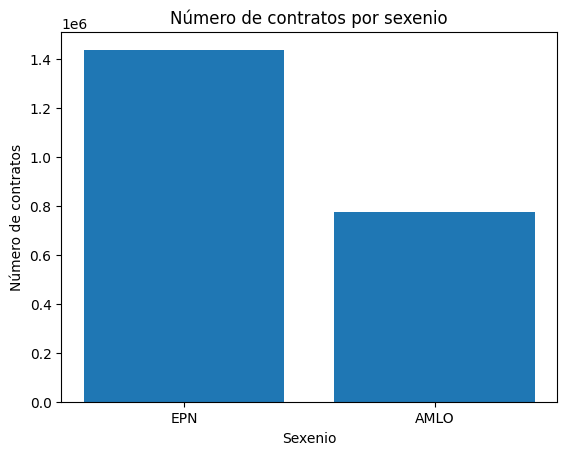

In [55]:
import matplotlib.pyplot as plt

contratos_pd = contratos_sexenio.toPandas()

plt.figure()
plt.bar(contratos_pd["sexenio"], contratos_pd["count"])
plt.xlabel("Sexenio")
plt.ylabel("Número de contratos")
plt.title("Número de contratos por sexenio")
plt.show()


### Monto total por sexenio

In [56]:
from pyspark.sql.functions import sum

monto_sexenio = df.groupBy("sexenio").agg(
    sum("importe").alias("monto_total")
)

monto_sexenio.show()

+-------+--------------------+
|sexenio|         monto_total|
+-------+--------------------+
|    EPN|3.201596488429855E12|
|   AMLO|2.315314620485941E12|
+-------+--------------------+



  sexenio   monto_total
0     EPN  3.201596e+12
1    AMLO  2.315315e+12


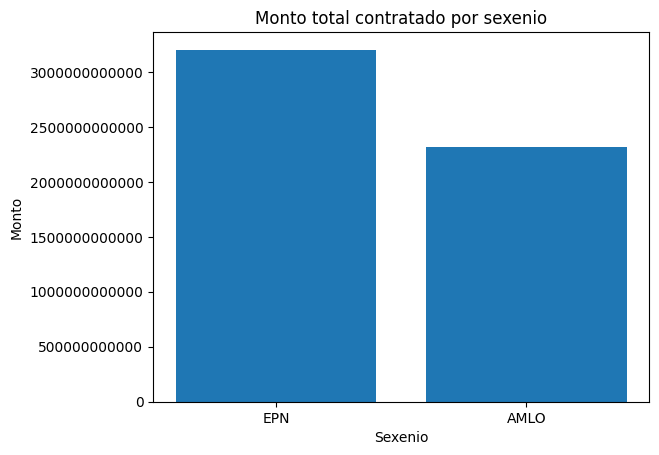

In [57]:
monto_pd = monto_sexenio.toPandas()

print(monto_pd)

import matplotlib.pyplot as plt

plt.figure()

plt.bar(monto_pd["sexenio"], monto_pd["monto_total"])

plt.title("Monto total contratado por sexenio")
plt.xlabel("Sexenio")
plt.ylabel("Monto")

plt.ticklabel_format(style='plain', axis='y')

plt.show()

### Modalidades de contratación

In [60]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "tipo_procedimiento",
    when(col("tipo_expediente").like("%Adjudicación Directa%"), "ADJUDICACION_DIRECTA")
    .when(col("tipo_expediente").like("%Invitación%"), "INVITACION_3")
    .when(col("tipo_expediente").like("%Licitación Pública%"), "LICITACION_PUBLICA")
    .otherwise("OTROS")
)

In [61]:
df.select("tipo_expediente","tipo_procedimiento").show(20, truncate=False)

+------------------------------------------------------------------------+--------------------+
|tipo_expediente                                                         |tipo_procedimiento  |
+------------------------------------------------------------------------+--------------------+
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|08. Reporte de otras contrataciones y c

In [62]:
modalidades = df.groupBy(
    "sexenio",
    "tipo_procedimiento"
).count()

In [63]:
modalidades_pd = modalidades.toPandas()

print(modalidades_pd.columns)

Index(['sexenio', 'tipo_procedimiento', 'count'], dtype='object')


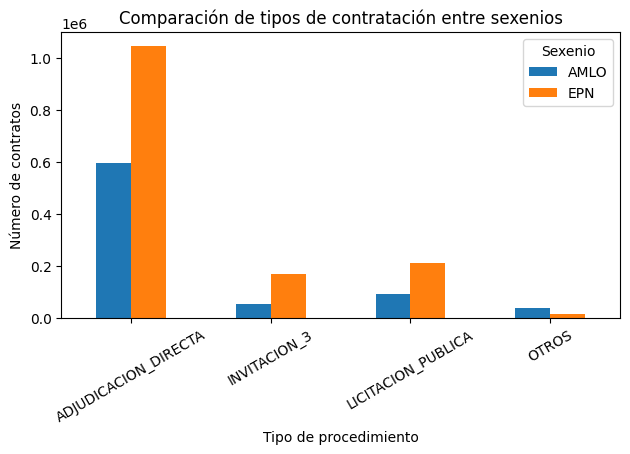

In [64]:
pivot = modalidades_pd.pivot(
    index="tipo_procedimiento",
    columns="sexenio",
    values="count"
)

pivot.plot(kind="bar")

import matplotlib.pyplot as plt

plt.title("Comparación de tipos de contratación entre sexenios")
plt.xlabel("Tipo de procedimiento")
plt.ylabel("Número de contratos")

plt.xticks(rotation=30)
plt.legend(title="Sexenio")

plt.tight_layout()
plt.show()

### Evolución temporal

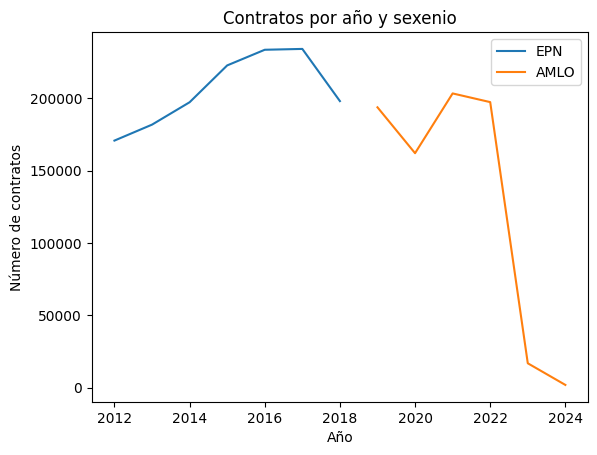

In [65]:
contratos_anio_pd = contrato_anio.toPandas()

plt.figure()
for s in contratos_anio_pd["sexenio"].unique():
  subset = contratos_anio_pd[contratos_anio_pd["sexenio"] == s]
  plt.plot(subset["anio"], subset["count"], label=s)

plt.legend()
plt.title("Contratos por año y sexenio")
plt.xlabel("Año")
plt.ylabel("Número de contratos")
plt.show()

## Modelos Logit

### Creación var binaria

In [70]:
from pyspark.sql.functions import when

df_logit = df.withColumn(
    "adjudicacion",
    when(col("tipo_expediente").like("%Adjudicación Directa%"), 1)
    .otherwise(0)
)


+---------------+-----------------+--------------------+---------------+-----------------+--------------------+-----------+------+-------------------+-------------------+----+-------+-------------+--------------------+------------+
|codigo_contrato|codigo_expediente|           proveedor|  contract_type|tipo_contratacion|     tipo_expediente|    importe|moneda|       fecha_inicio|          fecha_fin|anio|sexenio|duración_días|  tipo_procedimiento|adjudicacion|
+---------------+-----------------+--------------------+---------------+-----------------+--------------------+-----------+------+-------------------+-------------------+----+-------+-------------+--------------------+------------+
|        2376191|          2161394|Equity Appraisal ...|    3.Servicios|        Servicios|05. Adjudicación ...|    89012.0|   MXN|2020-07-22 05:00:00|2020-08-27 04:59:00|2020|   AMLO|           36|ADJUDICACION_DIRECTA|           1|
|        2376187|          2161390|Avaluos y Constru...|    3.Servicios|

In [72]:
pdf = df_logit.select(
    "adjudicacion",
    "importe",
    "duración_días",
    "anio"
).dropna().toPandas()

In [73]:
import statsmodels.api as sm

X = pdf[["importe", "duración_días", "anio"]]
y = pdf["adjudicacion"]

X = sm.add_constant(X)

logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Optimization terminated successfully.
         Current function value: inf
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           adjudicacion   No. Observations:              2213776
Model:                          Logit   Df Residuals:                  2213772
Method:                           MLE   Df Model:                            3
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                    -inf
Time:                        15:55:21   Log-Likelihood:                   -inf
converged:                       True   LL-Null:                   -1.2661e+06
Covariance Type:            nonrobust   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -101.6992      1.043    -97.485      0.000    -103.744     -99.654
importe       -1.923e-08 

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


## Redes de proveedores

### Tabla de relaciones

In [82]:
from pyspark.sql.functions import count

red = df.groupBy(
    "proveedor",
    "tipo_expediente"
).agg(
    count("*").alias("conteo")
)

In [83]:
red_filtrada = red.filter(col("conteo") > 50)

### Top Proveedores

In [84]:
from pyspark.sql.functions import sum

top_proveedores = df.groupBy("proveedor").agg(
    sum("importe").alias("monto_total")
).orderBy(col("monto_total").desc()).limit(50)

In [85]:
red_final = red_filtrada.join(
    top_proveedores.select("proveedor"),
    "proveedor"
)

### Convertir a Pandas

In [86]:
red_pd = red_final.toPandas()

### Creación de grafo

In [87]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for _, row in red_pd.iterrows():
    G.add_edge(
        row["proveedor"],
        row["tipo_expediente"],
        weight=row["conteo"]
    )

### Grafo

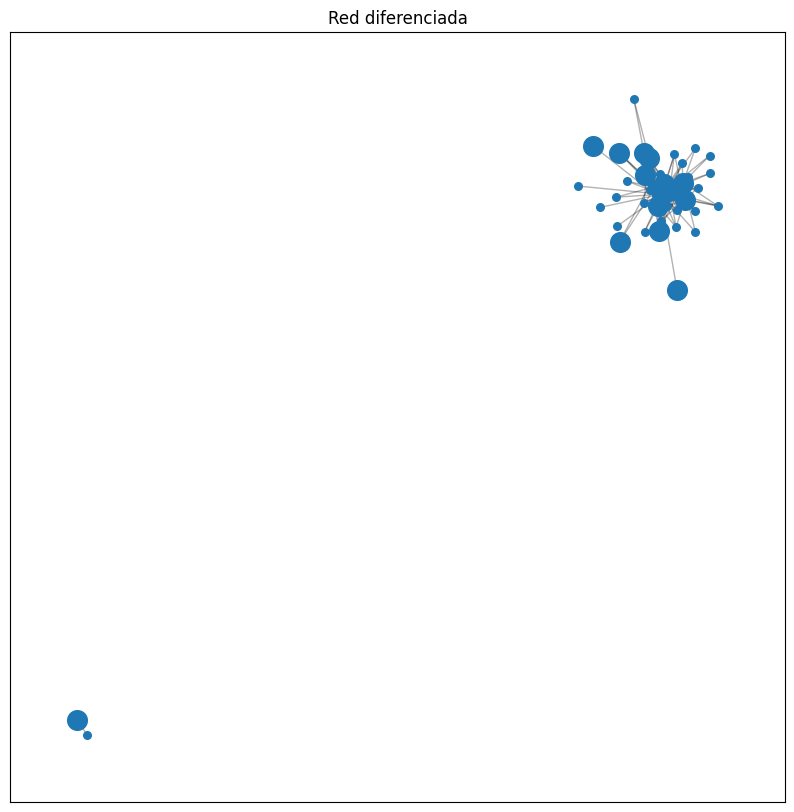

In [89]:
proveedores = [n for n in G.nodes if n in red_pd["proveedor"].values]
tipos = [n for n in G.nodes if n not in proveedores]

plt.figure(figsize=(10,10))

pos = nx.spring_layout(G)

nx.draw_networkx_nodes(G, pos, nodelist=proveedores, node_size=30)
nx.draw_networkx_nodes(G, pos, nodelist=tipos, node_size=200)

nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.title("Red diferenciada")
plt.show()

## Análisis de tendencia temporal

### Serie de tiempo

In [92]:
ts = df.groupBy(
    "anio",
    "sexenio"
).agg(
    sum("importe").alias("monto_total")
).orderBy("anio")

ts_pd = ts.toPandas()

### Regresión temporal

In [94]:
import numpy as np
from sklearn.linear_model import LinearRegression

for s in ts_pd["sexenio"].unique():
    subset = ts_pd[ts_pd["sexenio"] == s]

    X = subset["anio"].values.reshape(-1,1)
    y = subset["monto_total"].values

    model = LinearRegression()
    model.fit(X,y)

    print(f"Tendencia {s}:", model.coef_[0])

Tendencia EPN: 19099177697.42813
Tendencia AMLO: -72076179726.63239
